# Transformer versus Hi-Lo bankroll evaluation

I use this notebook to inspect the retained v6 transformer's scale result. The expensive simulation has already run through the tested package code, so this notebook loads the compact committed report instead of reimplementing the casino or replaying ten million policy-rounds.

My question was declared before the scale run: is the transformer's mean log-bankroll growth per paired shoe greater than the documented Hi-Lo control's? I call this outperformance only when the entire 95% confidence interval for transformer minus Hi-Lo is above zero.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

report_directory = project_root / "reports" / "blackjack-v6-bankroll"
report = json.loads((report_directory / "aggregate.json").read_text())
report_directory

/Users/pattrudel/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/mx/tjb7s2qs7vjdzq50cqzk4l7m0000gn/T/matplotlib-cc_agd1y because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/pattrudel/Projects/card-counting-llm/reports/blackjack-v6-bankroll')

## What I actually simulated

A “round” here means one policy completed one blackjack round. The transformer and Hi-Lo each receive the same shuffled shoe and cut-card position, but each advances its own cursor. Their hit, stand, double, and split choices can consume different numbers of cards, so their final round counts do not have to match.

In [2]:
round_counts = report["round_counts"]
summary = {
    "six-deck shoes": report["shoe_count"],
    "transformer rounds": round_counts["transformer"],
    "Hi-Lo rounds": round_counts["hi-lo"],
    "combined policy-rounds": round_counts["combined_policy_rounds"],
}
summary

{'six-deck shoes': 116000,
 'transformer rounds': 5015984,
 'Hi-Lo rounds': 5025662,
 'combined policy-rounds': 10041646}

## The predeclared statistical decision

I use log growth because wagers are fractions of current bankroll and therefore compound. Pairing by shoe removes some shuffle luck from the comparison. It does not pretend both policies see identical later hands after their actions diverge.

A confidence interval is a range produced by the observed between-shoe variation. If I repeated this sampling procedure many times, intervals built this way would contain the underlying mean about 95% of the time. It is not a 95% probability statement about this already-computed interval.

Verdict: transformer_outperforms_hi_lo
Mean transformer advantage per shoe: 0.00016734
95% CI: [0.00006587, 0.00026880]


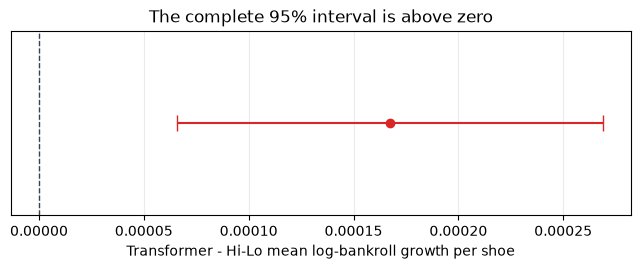

In [3]:
primary = report["primary_result"]
estimate = primary["estimate"]
mean = estimate["mean"]
lower, upper = estimate["confidence_interval_95"]

print(f"Verdict: {primary['verdict']}")
print(f"Mean transformer advantage per shoe: {mean:.8f}")
print(f"95% CI: [{lower:.8f}, {upper:.8f}]")

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.errorbar(
    [mean], [0],
    xerr=[[mean - lower], [upper - mean]],
    fmt="o", capsize=6, color="#dc2626",
)
ax.axvline(0, color="#374151", linewidth=1, linestyle="--")
ax.set_yticks([])
ax.set_xlabel("Transformer - Hi-Lo mean log-bankroll growth per shoe")
ax.set_title("The complete 95% interval is above zero")
ax.grid(axis="x", alpha=0.25)
plt.show()

The interval does not cross zero, so the scale run meets my predeclared definition of outperformance. This is narrower than saying the transformer beats every possible counting system: my control is six-deck H17 basic strategy plus the implemented Illustrious 18/Fab 4 deviations, insurance at true count +3, and the same four-level bet vocabulary.

## EV per round, per 100 rounds, and per hour

For a card-counting interpretation, I define one minimum-bet unit as `<BET_MIN>`, or 0.1% of bankroll. The four bet levels are therefore a 1-to-13 spread: 1, 5, 9, or 13 minimum-bet units.

I convert the already-retained arithmetic return into minimum-bet units. This keeps doubles, splits, insurance, naturals, and surrender in the realized profit. EV per hour is not a new simulation result; it is EV per round multiplied by an assumed table speed, so I show 60, 100, and 150 rounds/hour instead of claiming one universal rate.

Transformer: 1.737 min-bet units/100 rounds (95% CI 1.447 to 2.027)
  60 rounds/hour: 1.042 units/hour | 100 rounds/hour: 1.737 units/hour | 150 rounds/hour: 2.606 units/hour
Hi-Lo      : 1.258 min-bet units/100 rounds (95% CI 0.993 to 1.524)
  60 rounds/hour: 0.755 units/hour | 100 rounds/hour: 1.258 units/hour | 150 rounds/hour: 1.887 units/hour


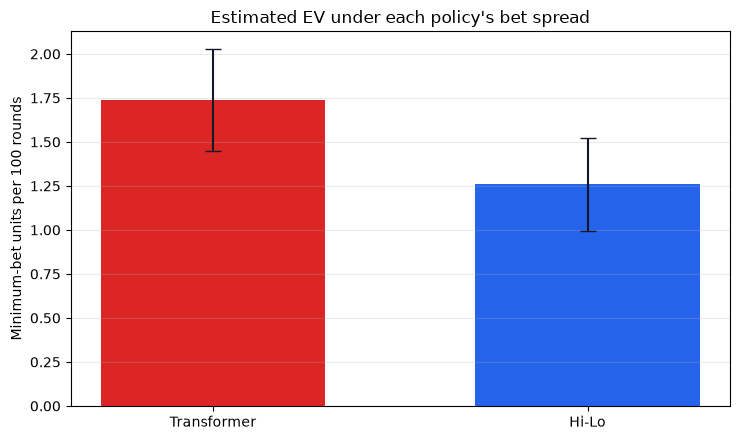

In [4]:
ev_labels = {"transformer": "Transformer", "hi-lo": "Hi-Lo"}
ev_colors = {"transformer": "#dc2626", "hi-lo": "#2563eb"}
policy_order = ("transformer", "hi-lo")

for policy_name in policy_order:
    ev = report["policies"][policy_name]["ev"]
    per_100 = ev["minimum_bet_units_per_100_rounds"]
    print(
        f"{ev_labels[policy_name]:11s}: {per_100['mean']:.3f} min-bet units/100 rounds "
        f"(95% CI {per_100['confidence_interval_95'][0]:.3f} to "
        f"{per_100['confidence_interval_95'][1]:.3f})"
    )
    hourly = ev["minimum_bet_units_per_hour"]
    print("  " + " | ".join(
        f"{rate} rounds/hour: {hourly[str(rate)]['mean']:.3f} units/hour"
        for rate in (60, 100, 150)
    ))

means = []
lower_errors = []
upper_errors = []
for policy_name in policy_order:
    estimate_100 = report["policies"][policy_name]["ev"][
        "minimum_bet_units_per_100_rounds"
    ]
    estimate_mean = estimate_100["mean"]
    estimate_lower, estimate_upper = estimate_100["confidence_interval_95"]
    means.append(estimate_mean)
    lower_errors.append(estimate_mean - estimate_lower)
    upper_errors.append(estimate_upper - estimate_mean)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(policy_order))
ax.bar(x, means, color=[ev_colors[name] for name in policy_order], width=0.6)
ax.errorbar(
    x,
    means,
    yerr=[lower_errors, upper_errors],
    fmt="none",
    color="#111827",
    capsize=6,
)
ax.set_xticks(x, [ev_labels[name] for name in policy_order])
ax.set_ylabel("Minimum-bet units per 100 rounds")
ax.set_title("Estimated EV under each policy's bet spread")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(report_directory / "ev_per_100_rounds.png", dpi=160)
plt.show()

The transformer estimate is 1.737 minimum-bet units per 100 rounds versus 1.258 for Hi-Lo, a descriptive gap of 0.479 units or about 38%. If my minimum bet were $25 and I played 100 rounds/hour, those estimates would be about $43.43/hour and $31.46/hour. That example implies a $25-to-$325 spread and ignores travel, tips, errors, heat, and other real-world costs.

I keep paired log growth as the predeclared hypothesis test because the bet sizes came from half-Kelly fractions and compound over time. EV per 100 rounds is the more interpretable headline, not a replacement metric selected to change the verdict.

## Seeing both bankroll paths

I use a logarithmic bankroll axis. Equal vertical distances then represent equal multiplicative growth. A linear axis would compress almost the entire five-million-round history against the bottom because repeated fractional wagers create exponential growth.

These endpoints are not literal casino forecasts. The simulator deliberately omits table limits, liquidity limits, bet camouflage, heat, and casino countermeasures. The paired confidence interval above is the evidence; this realized path is the intuitive picture.

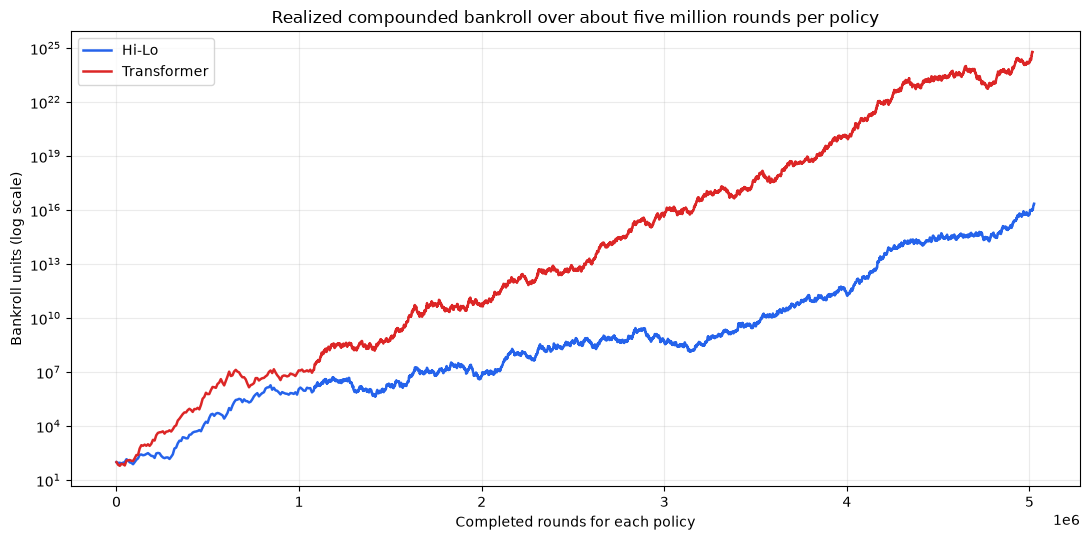

In [5]:
colors = {"transformer": "#dc2626", "hi-lo": "#2563eb"}
labels = {"transformer": "Transformer", "hi-lo": "Hi-Lo"}

fig, ax = plt.subplots(figsize=(11, 5.5))
for policy_name in ("hi-lo", "transformer"):
    points = report["policies"][policy_name]["trajectory"]
    rounds = [point["global_round_index"] for point in points]
    bankrolls = [point["bankroll_after"] for point in points]
    ax.semilogy(
        rounds,
        bankrolls,
        label=labels[policy_name],
        color=colors[policy_name],
        linewidth=1.8,
    )

ax.set_title("Realized compounded bankroll over about five million rounds per policy")
ax.set_xlabel("Completed rounds for each policy")
ax.set_ylabel("Bankroll units (log scale)")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(report_directory / "trajectory.png", dpi=160)
plt.show()

## Where the advantage appears

I retained three public-information breakdowns: shoe penetration, floored true count, and the share of publicly remaining cards that are Aces or ten-valued cards. These are diagnostics, not three new hypothesis tests. I use them to find failure regions rather than to redefine success after seeing the answer.

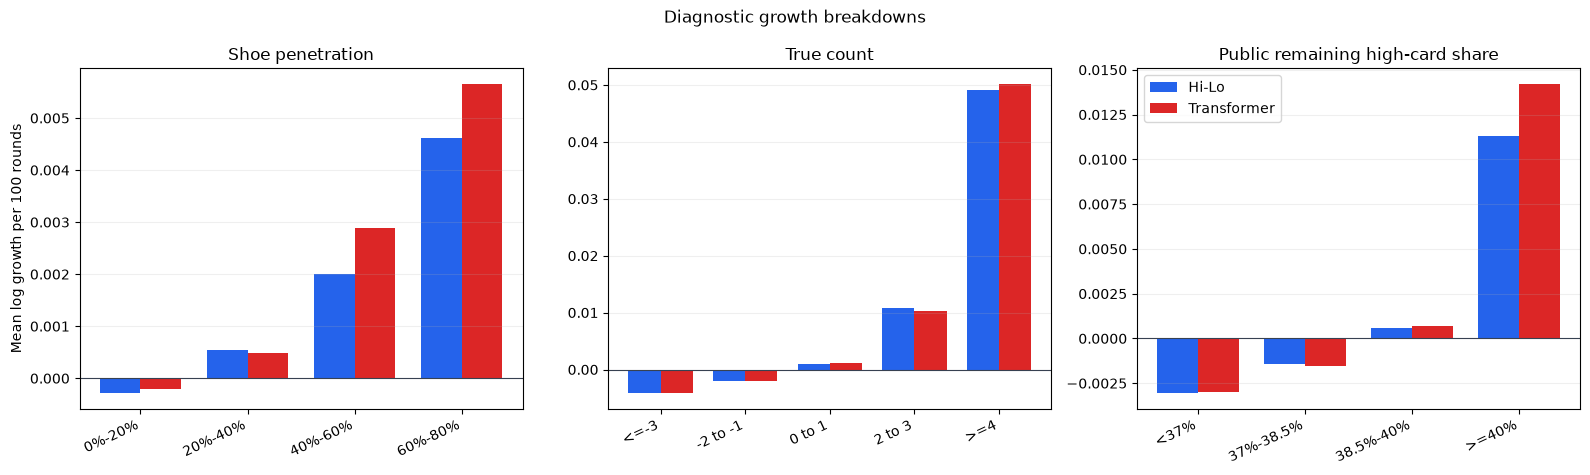

In [6]:
orders = {
    "penetration": ["0%-20%", "20%-40%", "40%-60%", "60%-80%"],
    "true_count": ["<=-3", "-2 to -1", "0 to 1", "2 to 3", ">=4"],
    "public_high_card_share": ["<37%", "37%-38.5%", "38.5%-40%", ">=40%"],
}
titles = {
    "penetration": "Shoe penetration",
    "true_count": "True count",
    "public_high_card_share": "Public remaining high-card share",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, category in zip(axes, orders, strict=True):
    bins = orders[category]
    x = np.arange(len(bins))
    width = 0.38
    for offset, policy_name in ((-width / 2, "hi-lo"), (width / 2, "transformer")):
        entries = {
            item["bin"]: item["mean_log_growth_per_100_rounds"]["mean"]
            for item in report["breakdowns"][category][policy_name]
        }
        ax.bar(
            x + offset,
            [entries[name] for name in bins],
            width,
            label=labels[policy_name],
            color=colors[policy_name],
        )
    ax.axhline(0, color="#374151", linewidth=0.8)
    ax.set_xticks(x, bins, rotation=25, ha="right")
    ax.set_title(titles[category])
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("Mean log growth per 100 rounds")
axes[-1].legend()
fig.suptitle("Diagnostic growth breakdowns")
fig.tight_layout()
fig.savefig(report_directory / "breakdowns.png", dpi=160)
plt.show()

The transformer is strongest relative to Hi-Lo at 40%–80% penetration and at a public remaining high-card share of at least 40%. It is slightly worse at 20%–40% penetration, true counts -2 to -1 and 2 to 3, and a 37%–38.5% high-card share. I would inspect these cases before adding capacity or post-training.

Both policies still have negative mean flat one-unit profit per round. That is compatible with positive bankroll growth: most ordinary states retain a house edge, while the betting policies risk tiny fractions there and more bankroll in favorable compositions.

In [7]:
for policy_name in ("transformer", "hi-lo"):
    policy = report["policies"][policy_name]
    flat_profit = policy["mean_profit_units_per_round"]["mean"]
    log_growth = policy["mean_log_growth_per_100_rounds"]["mean"]
    print(
        f"{labels[policy_name]:11s} | flat units/round {flat_profit:+.6f} "
        f"| log growth/100 rounds {log_growth:+.6f}"
    )

Transformer | flat units/round -0.003677 | log growth/100 rounds +0.001191
Hi-Lo       | flat units/round -0.004621 | log growth/100 rounds +0.000796


## The one context-boundary correction

One rare late-shoe decision had 257 tokens, while this retained model was trained with a 256-token window. I did not discard the round or substitute Hi-Lo. I changed the live evaluator to remove the minimum number of oldest visible-history card tokens while preserving the history marker, complete current hand, dealer upcard, structure markers, and query. The evaluator now records every occurrence.

This was a methodology correction after an observed boundary failure, so I document it rather than pretending it was predeclared. The earlier reports used fail-on-overflow behavior; because they completed, none contained an overlength decision.

In [8]:
report["transformer_context_statistics"]

{'instrumented_report_count': 1,
 'interpretation': 'uninstrumented reports used the former fail-on-overflow behavior, so they completed without any overlength decision',
 'maximum_original_length': 257,
 'maximum_tokens_dropped': 1,
 'measured_decision_count': 233436,
 'total_history_tokens_dropped': 1,
 'truncated_decision_count': 1,
 'uninstrumented_report_count': 40}

## How this compares with Stanford CS230 projects

I found two useful primary references: Stanford CS230's [2018 Deep Q-Learning project](https://cs230.stanford.edu/files_winter_2018/projects/6940282.pdf) and [2021 PPO project](https://cs230.stanford.edu/projects_fall_2021/reports/103066753.pdf).

The 2021 report is the closest high-level comparison. Its PPO agent used dealt-rank counts and dynamic betting, and it reported positive average reward against random, tabular, rule-based, Hi-Lo, and neural controls over 50,000 episodes. That supports the broad idea that a learned policy can exploit composition and betting information.

I cannot compare its reward number directly with mine. Its primary environment used one deck, omitted splitting, offered early surrender, made the dealer hit 17, and used a different action/reward setup. My environment uses six decks, American hole-card rules, H17, splits and split restrictions, late surrender, insurance, exact payouts, and visible card-token history. I also train by supervised imitation of Monte Carlo labels rather than deep reinforcement learning. The defensible comparison is methodological: both learned systems beat their own documented controls under their own rules.

## What I conclude

I now have statistically resolved evidence that this retained transformer outperforms the predeclared Hi-Lo control on paired log-bankroll growth in my simulator. I do not need another training run to make that statement.

My next useful work is interpretability and targeted failure analysis: probe whether hidden states encode running count, true count, or richer rank composition; inspect attention over visible history; and study the narrow regions where Hi-Lo remains ahead. A future architecture experiment can remove the rare 256-token boundary with a longer window or an explicitly sufficient composition representation.